In [1]:
import jax
import jax.numpy as jnp
import tqdm
import blackjax

from jax import jit

import jax.numpy as jnp
from jax import jit
from ceridwen.ssps.ssp_data import SSPData, collect_ssp_data_wrapper
from ceridwen.csp.csp import CSPBasis
import astropy.constants as const

import matplotlib.pyplot as plt
import fsps

jax.config.update("jax_enable_x64", True)

In [2]:
ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

csp = CSPBasis(ssp_data)
tuniv = 13.8
gal_t_table = jnp.linspace(0.1, 13.78, 3)
gal_sfr_table = jnp.linspace(0.1, 10, len(gal_t_table))
gal_z_table = jnp.ones_like(gal_sfr_table)*csp.zlegend[0] #jnp.array([4.49043431e-05, 1.42000001e-04, 2.52515678e-04, 4.49043431e-04,
       #7.98524687e-04, 1.42000001e-03, 2.52515678e-03, 4.49043431e-03,
       #7.98524687e-03, 1.42000001e-02, 1.42000001e-02, 1.42000001e-02])

csp.add_sfh(sfh=gal_sfr_table, lookback_time=13.8 - gal_t_table)
csp.add_zh(zh=gal_z_table, lookback_time=13.8 - gal_t_table)
spectrum1 = csp.get_spectrum()


lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


In [3]:
rng_key = jax.random.PRNGKey(0)
num_dims = len(gal_sfr_table) + len(gal_z_table) 
num_live = 1000
num_inner_steps = num_dims * 5
num_delete = num_live // 2

# Define Data and Likelihood

lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


(1e-05, 0.0001)

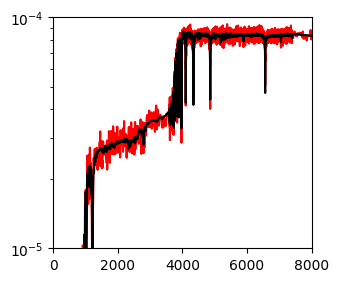

In [4]:
num_time_bins = 3
gal_t_table = jnp.linspace(0.1, 13.78, num_time_bins)

# True parameters
true_sfh = jnp.linspace(0.1, 10, num_time_bins)
true_zh = jnp.ones_like(true_sfh) * csp.zlegend[0]

# Create "true" spectrum
csp_true = CSPBasis(ssp_data)
csp_true.add_sfh(sfh=true_sfh, lookback_time=13.8 - gal_t_table)
csp_true.add_zh(zh=true_zh, lookback_time=13.8 - gal_t_table)
spectrum_clean = csp_true.get_spectrum()

# Add noise
key, rng_key = jax.random.split(rng_key)
sigma = 0.03 * jnp.max(spectrum_clean)  # relative noise level
noise = sigma * jax.random.normal(key, shape=spectrum_clean.shape)
spectrum_obs = spectrum_clean + noise

plt.figure(figsize=(10/3, 3))
plt.plot(csp_true.wave, spectrum_obs, label='Observed Spectrum', color='red')
plt.plot(csp_true.wave, csp_true.spectrum, label='CSP Spectrum', color='black')
#plt.errorbar(csp_true.wave, spectrum_obs, yerr=jnp.abs(noise), label='Clean Spectrum', color='blue')
plt.xlim(0, 8000)
plt.yscale('log')
plt.ylim(1e-5, 1e-4)

In [5]:
from functools import partial
from jax import jit, grad

csp = CSPBasis(ssp_data)

sfh = jnp.ones_like(gal_t_table)  # Initial guess for SFH
zh = jnp.ones_like(gal_t_table) * csp.zlegend[2]
csp.add_sfh(sfh=sfh, lookback_time=13.8 - gal_t_table) #need to set sfh_times 
model = partial(csp.get_spectrum_direct)  # csp is now static

# JIT works
model_jit = jit(model)
spectrum = model_jit(sfh, zh)

# grad also works (with respect to sfh, for example)
grad_spectrum = grad(lambda sfh: jnp.sum(model(sfh, zh)))(sfh)

lookback time


(1e-07, 0.0001)

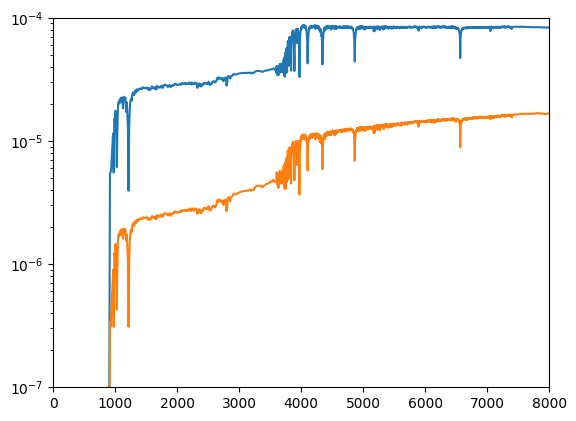

In [6]:
plt.plot(csp.wave, model(true_sfh, true_zh))
plt.plot(csp.wave, model(sfh, zh))
plt.xlim(0, 8000)
plt.yscale('log')
plt.ylim(1e-7, 1e-4)

In [9]:
true_zh

Array([4.49043509e-05, 4.49043509e-05, 4.49043509e-05], dtype=float64)

In [11]:
csp.zlegend

Array([4.4904351e-05, 1.4200011e-04, 2.5251572e-04, 4.4904376e-04,
       7.9852482e-04, 1.4200003e-03, 2.5251573e-03, 4.4904351e-03,
       7.9852482e-03, 1.4200003e-02, 2.5251573e-02, 4.4904351e-02],      dtype=float32)

## 3. Define the prior function

 Here we use uniform priors for the parameters.

In [13]:
n_bins = len(gal_t_table)
prior_bounds = {}

for i in range(n_bins):
    prior_bounds[f"sfh_{i}"] = (0.001, 12.0)     # Msun/yr
    prior_bounds[f"zh_{i}"]  = (3e-5, 3e-4)      # Z
prior_bounds["sigma"] = (1e-7, 1e-2)              # flux error

prior_bounds

{'sfh_0': (0.001, 12.0),
 'zh_0': (3e-05, 0.0003),
 'sfh_1': (0.001, 12.0),
 'zh_1': (3e-05, 0.0003),
 'sfh_2': (0.001, 12.0),
 'zh_2': (3e-05, 0.0003),
 'sigma': (1e-07, 0.01)}

In [15]:
def unpack_params(params_flat, n_bins):
    sfh = jnp.array([params_flat[f"sfh_{i}"] for i in range(n_bins)])
    zh  = jnp.array([params_flat[f"zh_{i}"]  for i in range(n_bins)])
    sigma = params_flat["sigma"]
    return sfh, zh, sigma

def loglikelihood_fn(params_flat):
    sfh, zh, sigma = unpack_params(params_flat, n_bins)
    mu = model(sfh, zh)
    cov = sigma ** 2
    lgl = jax.scipy.stats.multivariate_normal.logpdf(spectrum_obs, mu, cov)
    return lgl

In [16]:
from blackjax.ns.utils import uniform_prior

rng_key, prior_key = jax.random.split(rng_key)
particles, logprior_fn = uniform_prior(prior_key, num_live, prior_bounds)

In [17]:
i = 0  # index of the live particle you want to test
params_test = {k: v[i] for k, v in particles.items()}

# Evaluate the likelihood
ll = loglikelihood_fn(params_test)

print("Log-likelihood:", ll)

Log-likelihood: 22219.779084241974


In [18]:
params_test = {'sfh_0': jnp.array([6.89615003, 3]),
 'sfh_1': jnp.array([2.78799016, 4]),
 'sfh_2': jnp.array([2.02322524, 5]),
 'sigma': jnp.array([0.0059143, 0.001]),
 'zh_0': jnp.array([0.00010885, 0.00044]),
 'zh_1': jnp.array([0.0002968, 0.0008]),
 'zh_2': jnp.array([0.0001728, 0.0009])}


lls = jax.vmap(loglikelihood_fn)(params_test)


print("Log-likelihoods:", lls)
print("Any NaNs?", jnp.any(jnp.isnan(lls)))
print("All -inf?", jnp.all(lls == -jnp.inf))

Log-likelihoods: [25243.27082342 35895.60937468]
Any NaNs? False
All -inf? False


In [44]:
def dict_of_arrays_to_list_of_dicts(dict_of_arrays):
    """Convert batched dict-of-arrays to list of dicts (each sample is a dict)."""
    keys = dict_of_arrays.keys()
    n = next(iter(dict_of_arrays.values())).shape[0]
    return [{k: dict_of_arrays[k][i] for k in keys} for i in range(n)]

params_list = dict_of_arrays_to_list_of_dicts(particles)
lls = jnp.array([loglikelihood_fn(p) for p in params_list])

Log-likelihood: 25243.269528672634
Log-likelihood: 30535.578648079903
Log-likelihood: 26196.47360198397
Log-likelihood: 22390.175212122816
Log-likelihood: 23980.94484076694
Log-likelihood: 27398.035410468714
Log-likelihood: 23327.953691866933
Log-likelihood: 35144.105997602855
Log-likelihood: 45504.4642720645
Log-likelihood: 24804.998386164116
Log-likelihood: 36756.44090114206
Log-likelihood: 28470.260990758892
Log-likelihood: 22739.273880615976
Log-likelihood: 28452.947488918468
Log-likelihood: 22397.89060047224
Log-likelihood: 31862.803542557413
Log-likelihood: 25631.395978530905
Log-likelihood: 30293.946360843296
Log-likelihood: 22267.299873775974
Log-likelihood: 29136.61286937103
Log-likelihood: 34848.23517197839
Log-likelihood: 41166.57507486097
Log-likelihood: 22542.554233251227
Log-likelihood: 27076.53703329014
Log-likelihood: 23914.050752510848
Log-likelihood: 26716.385577179954
Log-likelihood: 26901.02575399157
Log-likelihood: 24839.3581850831
Log-likelihood: 22326.237853204
L

In [49]:
lls[717]

Array(-2642682.96765975, dtype=float64)

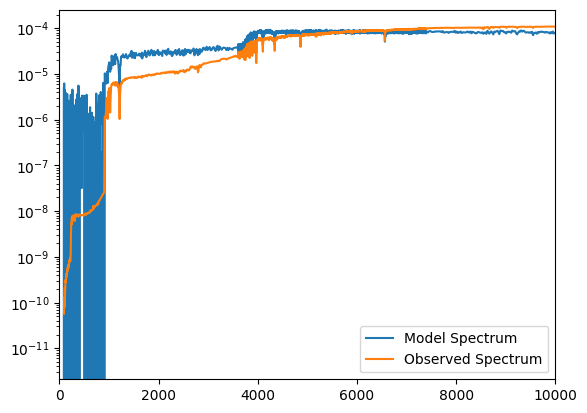

In [19]:
plt.plot(csp.wave,spectrum_obs, label='Model Spectrum')
plt.plot(csp.wave,model(sfh=jnp.array([3.44929398, 10.28902141, 3.28966267]),
            zh=jnp.array([0.00010805, 0.00029539, 0.00019649])), label='Observed Spectrum')
plt.xlim(0, 10000)
plt.yscale('log') 
plt.legend()  

In [ ]:
unpack_params(params_list[717])

{'sfh_0': Array(3.44929398, dtype=float64),
 'sfh_1': Array(10.28902141, dtype=float64),
 'sfh_2': Array(3.28966267, dtype=float64),
 'sigma': Array(4.76082239e-07, dtype=float64),
 'zh_0': Array(0.00010805, dtype=float64),
 'zh_1': Array(0.00029539, dtype=float64),
 'zh_2': Array(0.00019649, dtype=float64)}

In [45]:

print("Log-likelihoods:", lls)
print("Any NaNs?", jnp.any(jnp.isnan(lls)))
print("All -inf?", jnp.all(lls == -jnp.inf))

Log-likelihoods: [   25243.26952867    30535.57864808    26196.47360198    22390.17521212
    23980.94484077    27398.03541047    23327.95369187    35144.1059976
    45504.46427206    24804.99838616    36756.44090114    28470.26099076
    22739.27388062    28452.94748892    22397.89060047    31862.80354256
    25631.39597853    30293.94636084    22267.29987378    29136.61286937
    34848.23517198    41166.57507486    22542.55423325    27076.53703329
    23914.05075251    26716.38557718    26901.02575399    24839.35818508
    22326.2378532     25124.76336887    34699.37664971    25855.1970312
    24096.56274388    25353.04439911    22422.09183833    22233.98839869
    24868.53033839    22176.8719517     23270.75003353    23949.342961
    25000.69890962    22680.81054446    25278.67252746    24075.72268952
    29646.78238309    35059.35085025    24844.36522735    23272.46130882
    22384.6682244     22700.46109052    26147.26834003    30031.25681334
    27924.28340649    22414.12302504  

In [39]:
lls = jax.vmap(loglikelihood_fn)(params_test)


Log-likelihood: Traced<ShapedArray(float64[])>with<BatchTrace> with
  val = Array([25243.27082342, 35895.60937468], dtype=float64)
  batch_dim = 0


In [40]:
print("Log-likelihoods:", lls)
print("Any NaNs?", jnp.any(jnp.isnan(lls)))
print("All -inf?", jnp.all(lls == -jnp.inf))

Log-likelihoods: [25243.27082342 35895.60937468]
Any NaNs? False
All -inf? False


In [20]:
nested_sampler = blackjax.nss(
    logprior_fn=logprior_fn,
    loglikelihood_fn=loglikelihood_fn,
    num_delete=num_delete,
    num_inner_steps=num_inner_steps,
)
init_fn = jax.jit(nested_sampler.init)
step_fn = jax.jit(nested_sampler.step)

live = init_fn(particles)

# Here

In [ ]:
# Check log-likelihoods for all initial particles
lls = jax.vmap(loglikelihood_fn)(particles)
print("Log-likelihoods:", lls)
print("Any NaNs?", jnp.any(jnp.isnan(lls)))
print("All -inf?", jnp.all(lls == -jnp.inf))

In [56]:
live.logZ_live

Array(-inf, dtype=float64, weak_type=True)

In [65]:
params_test = {k: v[i] for k, v in particles.items()}
sfh, zh, sigma = unpack_params(params_test, n_bins)
mu = model(sfh, zh)
print("mu has NaNs?", jnp.any(jnp.isnan(mu)))

mu has NaNs? False


In [ ]:
nested_sampler = blackjax.nss(
    logprior_fn=logprior_fn,
    loglikelihood_fn=loglikelihood_fn,
    num_delete=num_delete,
    num_inner_steps=num_inner_steps,
)
init_fn = jax.jit(nested_sampler.init)
step_fn = jax.jit(nested_sampler.step)

live = init_fn(particles)
dead = []
with tqdm.tqdm(desc="Dead points", unit=" dead points") as pbar:
    while not live.logZ_live - live.logZ < -3:
        print(f"Current logZ: {live.logZ_live - live.logZ}")
        rng_key, subkey = jax.random.split(rng_key, 2)
        live, dead_info = step_fn(subkey, live)
        dead.append(dead_info)
        pbar.update(num_delete)

dead = blackjax.ns.utils.finalise(live, dead)

Dead points: 0 dead points [00:00, ? dead points/s]

Current logZ: nan


Dead points: 500 dead points [01:04,  7.70 dead points/s]

In [14]:
target_dead_points = 50

dead = []
iteration = 0
with tqdm.tqdm(desc="Dead points", unit=" dead points") as pbar:
    while len(dead) * num_delete < target_dead_points:
        if iteration % 1 == 0:  # every step in short run
            print(f"[{iteration}] logZ = {live.logZ:.2f}, ΔlogZ = {live.logZ_live - live.logZ:.2f}")
        rng_key, subkey = jax.random.split(rng_key, 2)
        live, dead_info = step_fn(subkey, live)
        dead.append(dead_info)
        pbar.update(num_delete)

Dead points: 0 dead points [00:00, ? dead points/s]

[0] logZ = -inf, ΔlogZ = nan
Log-likelihood: Traced<ShapedArray(float64[])>with<BatchTrace> with
  val = Traced<ShapedArray(float64[500])>with<DynamicJaxprTrace>
  batch_dim = 0
Log-likelihood: Traced<ShapedArray(float64[])>with<DynamicJaxprTrace>
Log-likelihood: Traced<ShapedArray(float64[])>with<DynamicJaxprTrace>
Log-likelihood: Traced<ShapedArray(float64[])>with<DynamicJaxprTrace>
Log-likelihood: Traced<ShapedArray(float64[])>with<BatchTrace> with
  val = Traced<ShapedArray(float64[500])>with<DynamicJaxprTrace>
  batch_dim = 0


Dead points: 500 dead points [00:03, 163.13 dead points/s]


In [15]:
dead = blackjax.ns.utils.finalise(live, dead)

In [16]:
particles.keys()

dict_keys(['sfh_0', 'sfh_1', 'sfh_2', 'sigma', 'zh_0', 'zh_1', 'zh_2'])

In [17]:
from anesthetic import NestedSamples
columns = ['sfh_0', 'sfh_1', 'sfh_2', 'sigma', 'zh_0', 'zh_1', 'zh_2']
labels = [r"$sfh_0$", r"$sfh_1$", r"$sfh_2$", r"$\sigma$", r"$zh_0$", r"$zh_1$", r"$zh_2$"]

In [17]:
data = jnp.vstack([dead.particles[key] for key in columns]).T

In [ ]:
print('hello')

In [ ]:


samples = NestedSamples(
    data,
    logL=dead.loglikelihood,
    logL_birth=dead.loglikelihood_birth,
    columns=columns,
    labels=labels,
    logzero=jnp.nan,
)
samples.to_csv("test1_ceridwen.csv")

In [ ]:
from anesthetic import read_chains
samples = read_chains("test1_ceridwen.csv")

In [ ]:
kinds ={'lower': 'kde_2d', 'diagonal': 'hist_1d', 'upper': 'scatter_2d'}
axes = samples.prior().plot_2d(['sfh_0', 'sfh_1', 'sfh_2', 'sigma', 'zh_0', 'zh_1', 'zh_2'], kinds=kinds, label='prior')
samples.plot_2d(axes, kinds=kinds, label='posterior')